<a href="https://colab.research.google.com/github/ShahSayem/Alzheimer-Disease-Detection/blob/main/2A-OASIS_Alzheimer_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ninadaithal_imagesoasis_path = kagglehub.dataset_download('ninadaithal/imagesoasis')

print('Data source import complete.')


In [ ]:
!pip install --upgrade scikit-learn
!pip install --upgrade imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 88.1 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 96.2 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.0
    Uninstalling scikit-learn-1.7.0:
      Successfully uninstalled sc

In [ ]:
import keras
import seaborn as sns
import matplotlib.pyplot as plt
from keras.models import Sequential
import PIL
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from keras.layers import Conv2D,Flatten,Dense,Dropout,BatchNormalization,MaxPooling2D
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping,ModelCheckpoint
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tqdm import tqdm
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

2025-06-16 11:37:25.581299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750073845.785821      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750073845.841528      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
non_demented = []
very_mild_demented = []
mild_demented = []
moderate_demented = []

# Download per category
for dirname, _, filenames in os.walk('/kaggle/input/imagesoasis/Data/Non Demented'):
    for filename in filenames:
        non_demented.append(os.path.join(dirname, filename))

for dirname, _, filenames in os.walk('/kaggle/input/imagesoasis/Data/Very mild Dementia'):
    for filename in filenames:
        very_mild_demented.append(os.path.join(dirname, filename))

for dirname, _, filenames in os.walk('/kaggle/input/imagesoasis/Data/Mild Dementia'):
    for filename in filenames:
        mild_demented.append(os.path.join(dirname, filename))

for dirname, _, filenames in os.walk('/kaggle/input/imagesoasis/Data/Moderate Dementia'):
    for filename in filenames:
        moderate_demented.append(os.path.join(dirname, filename))

In [ ]:
images = []
labels = []
for subfolder in tqdm(os.listdir('/kaggle/input/imagesoasis')):
    subfolder_path = os.path.join('/kaggle/input/imagesoasis', subfolder)
    for folder in os.listdir(subfolder_path):
        subfolder_path2=os.path.join(subfolder_path,folder)
        for image_filename in os.listdir(subfolder_path2):
            image_path = os.path.join(subfolder_path2, image_filename)
            images.append(image_path)
            labels.append(folder)
df = pd.DataFrame({'image': images, 'label': labels})
df

100%|██████████| 1/1 [00:00<00:00,  9.33it/s]


,image,label
0,/kaggle/input/imagesoasis/Data/Non Demented/OA...,Non Demented
1,/kaggle/input/imagesoasis/Data/Non Demented/OA...,Non Demented
2,/kaggle/input/imagesoasis/Data/Non Demented/OA...,Non Demented
3,/kaggle/input/imagesoasis/Data/Non Demented/OA...,Non Demented
4,/kaggle/input/imagesoasis/Data/Non Demented/OA...,Non Demented
...,...,...
86432,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia
86433,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia
86434,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia
86435,/kaggle/input/imagesoasis/Data/Mild Dementia/O...,Mild Dementia


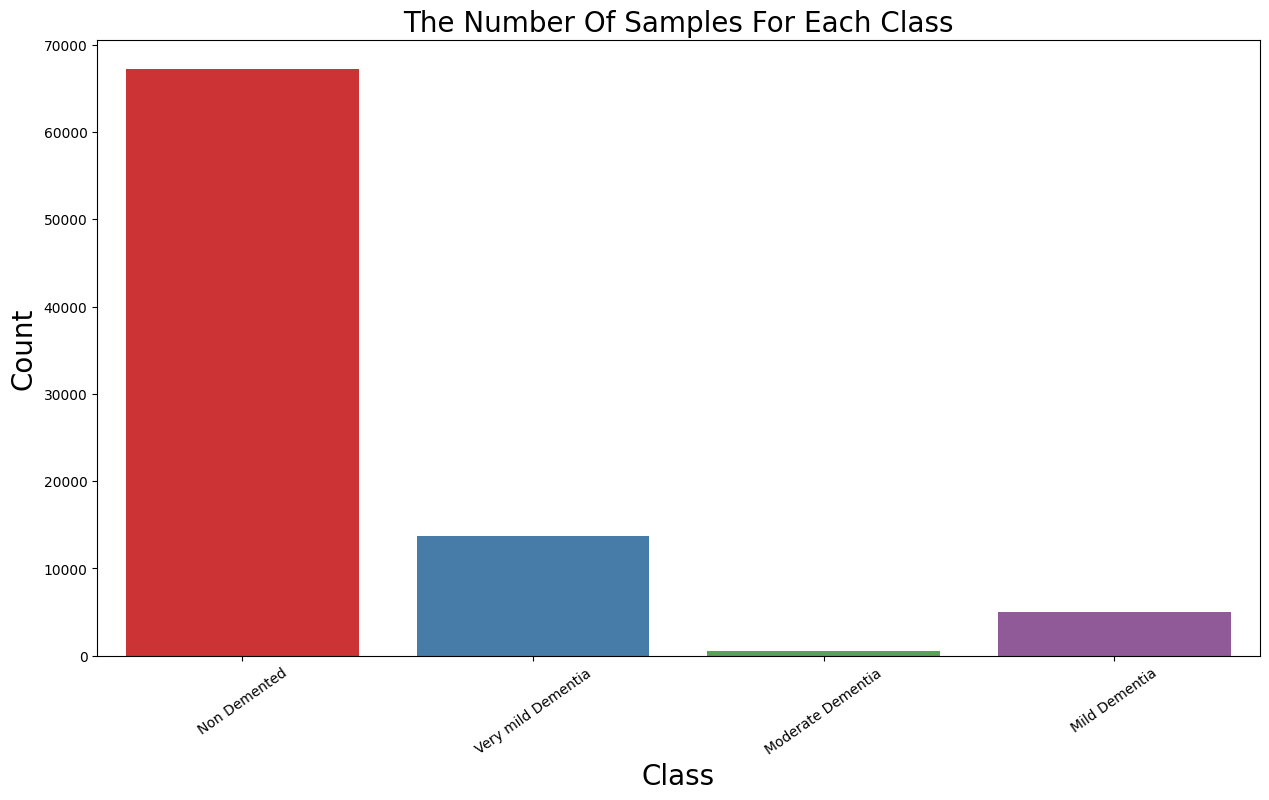

In [ ]:
plt.figure(figsize=(15,8))
ax = sns.countplot(x=df.label,palette='Set1')
ax.set_xlabel("Class",fontsize=20)
ax.set_ylabel("Count",fontsize=20)
plt.title('The Number Of Samples For Each Class',fontsize=20)
plt.grid(False)
plt.xticks(rotation=35)
plt.show()

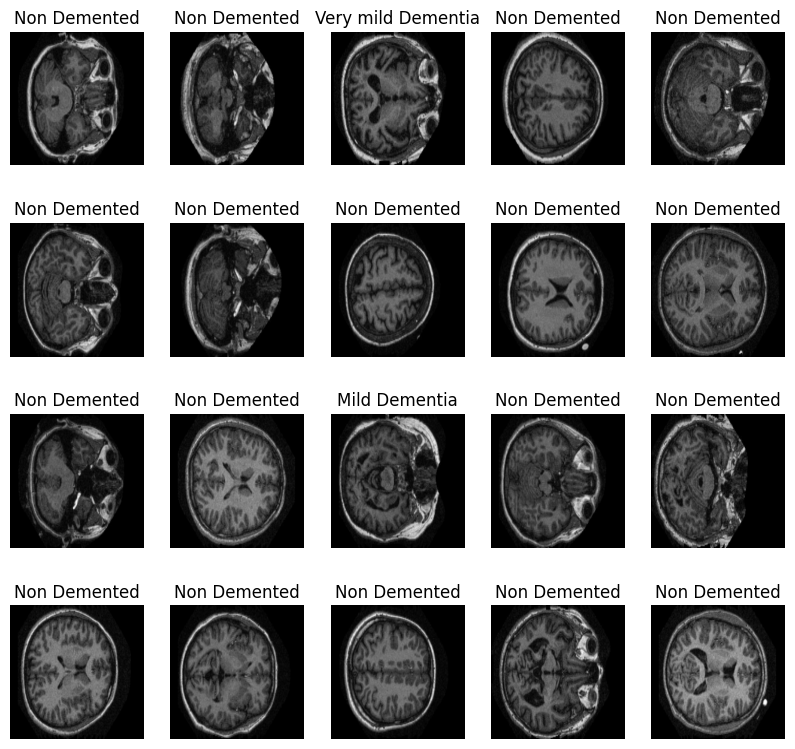

In [ ]:
plt.figure(figsize=(10,12))
for n,i in enumerate(np.random.randint(0,len(df),20)):
    plt.subplot(5,5,n+1)
    img=cv2.imread(df.image[i])
    img=cv2.resize(img,(224,224))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.title(df.label[i],fontsize=12)

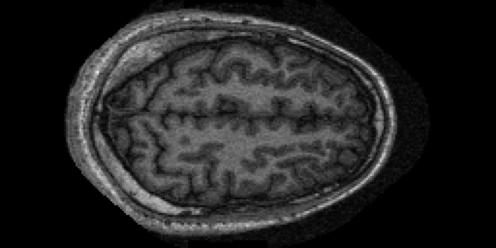

In [ ]:
PIL.Image.open(str(non_demented[0]))

In [ ]:
print(len(non_demented))
print(len(mild_demented))
print(len(moderate_demented))
print(len(very_mild_demented))

67222
5002
488
13725


# Make all the catagory have same number of images

In [ ]:
# non_demented=non_demented[0:488]
# mild_demented=mild_demented[0:488]
# very_mild_demented=very_mild_demented[0:488]

# One Hot Encoding
0 -> non_demented

1 -> mild_dementia

2 -> moderate_dementia

3 -> very_mild_dementia

In [ ]:
encoder= OneHotEncoder()
encoder.fit([[0],[1],[2],[3]])

OneHotEncoder()

# Data proccessing
transfer data into 128x128x3 shape

In [ ]:
data = []
result = []
for s in non_demented:
    img = Image.open(s)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[0]]).toarray())

for s in mild_demented:
    img = Image.open(s)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[1]]).toarray())

for s in moderate_demented:
    img = Image.open(s)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[2]]).toarray())

for s in very_mild_demented:
    img = Image.open(s)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[3]]).toarray())

# Reshape the data

In [ ]:
X=np.array(data)
X.shape

(86437, 128, 128, 3)

In [ ]:
y=np.array(result)
y=y.reshape(X.shape[0],4)
y=np.argmax(y, axis=1)
y

array([0, 0, 0, ..., 3, 3, 3])

# splitting the data

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42, shuffle = True)

In [ ]:
X_train.shape

(69149, 128, 128, 3)

In [ ]:
X_test.shape

(17288, 128, 128, 3)

# Creating Model

In [ ]:
model=Sequential()

In [ ]:
model.add(Conv2D(filters=32,kernel_size=2,padding='Same',input_shape = (128,128,3)))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1750074767.804101      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
model.add(Conv2D(filters=32,kernel_size=2,padding='Same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(filters=64,kernel_size=2,padding='Same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=2,padding='Same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(filters=128,kernel_size=2,padding='Same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=2,padding='Same',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(4,activation='softmax'))

In [ ]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       8,388,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,518,596 (32.50 MB)

 Trainable params: 8,518,148 (32.49 MB)

 Non-trainable params: 448 (1.75 KB)

None


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0,
)

In [ ]:
history= model.fit(X_train,y_train, validation_split=0.2,epochs=15,callbacks=[early_stopping],batch_size=128)

Epoch 1/15


I0000 00:00:1750074781.374333     115 service.cc:148] XLA service 0x7f5d88004000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750074781.375292     115 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1750074781.916009     115 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/433 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - accuracy: 0.3418 - loss: 15.2646  

I0000 00:00:1750074790.305970     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


433/433 ━━━━━━━━━━━━━━━━━━━━ 54s 92ms/step - accuracy: 0.7490 - loss: 2.3359 - val_accuracy: 0.7905 - val_loss: 0.4658
Epoch 2/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.8956 - loss: 0.2532 - val_accuracy: 0.9725 - val_loss: 0.0780
Epoch 3/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.9543 - loss: 0.1173 - val_accuracy: 0.9661 - val_loss: 0.0941
Epoch 4/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.9729 - loss: 0.0738 - val_accuracy: 0.9565 - val_loss: 0.1239
Epoch 5/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.9783 - loss: 0.0606 - val_accuracy: 0.9696 - val_loss: 0.0987
Epoch 6/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.9839 - loss: 0.0439 - val_accuracy: 0.9928 - val_loss: 0.0205
Epoch 7/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.9871 - loss: 0.0347 - val_accuracy: 0.9978 - val_loss: 0.0081
Epoch 8/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.9891 - loss: 0.0312 - val_accurac

In [ ]:
model.evaluate(X_test,y_test)

541/541 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9990 - loss: 0.0029


[0.0020140553824603558, 0.9993059039115906]

# Test & Evaluation

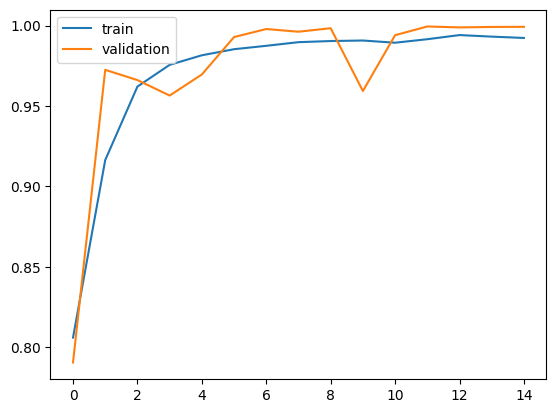

In [ ]:
%matplotlib inline
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')
plt.legend()
plt.show()

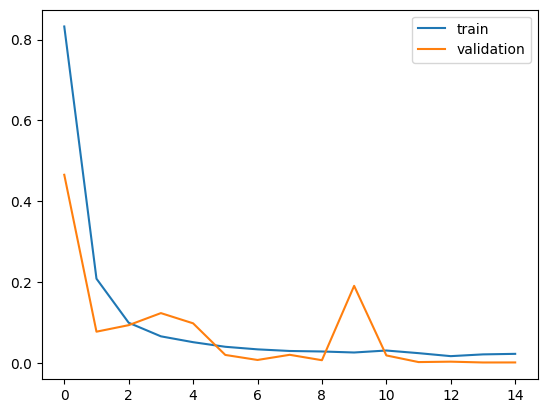

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')
plt.legend()
plt.show()

In [ ]:
class_name = {0: "Mild Dementia",1: "Moderate Dementia" , 2: "Non Demented", 3: "Very mild Dementia"}

In [ ]:
test_scores = model.evaluate(X_test,y_test)
test_scores

541/541 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9990 - loss: 0.0029


[0.0020140553824603558, 0.9993059039115906]

In [ ]:
predicted_test_labels = model.predict(X_test)
res = model.predict(X_test)
predicted_test_labels =  np.argmax(predicted_test_labels,axis= 1 )
predicted_test_labels[1]

541/541 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
541/541 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


0

In [ ]:
ypred = []
for i in res:
  temp = np.argmax(i)
  ypred.append(temp)
ypred = np.array(ypred)

In [ ]:
accuracy_score(y_test,ypred)

0.9993058769088385

<Figure size 640x480 with 0 Axes>

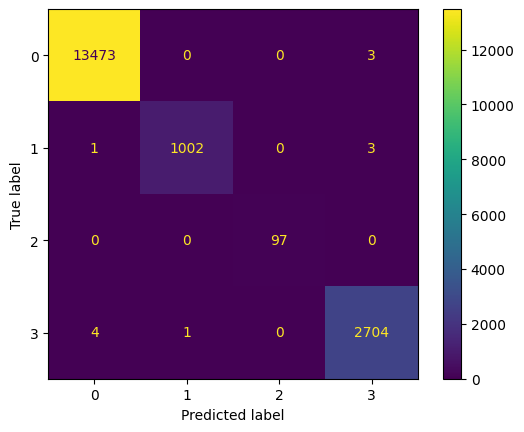

In [ ]:
cf = confusion_matrix(y_true = y_test ,y_pred =  ypred)
plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

x = ConfusionMatrixDisplay(cf)
x.plot()

In [ ]:
print(classification_report(y_true = y_test ,y_pred =  ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13476
           1       1.00      1.00      1.00      1006
           2       1.00      1.00      1.00        97
           3       1.00      1.00      1.00      2709

    accuracy                           1.00     17288
   macro avg       1.00      1.00      1.00     17288
weighted avg       1.00      1.00      1.00     17288

